In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import cdsapi
from pycontrails import Flight, MetDataset
from pycontrails.datalib.ecmwf import ERA5
from pycontrails.models.cocip import (
    Cocip,
    flight_waypoint_summary_statistics,
    contrail_flight_summary_statistics,
    natural_cirrus_properties_to_hi_res_grid,
)
from pycontrails.models.humidity_scaling import ConstantHumidityScaling

plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
time_bounds = ("2022-03-01 00:00:00", "2022-03-01 23:00:00")
pressure_levels = (300, 250, 200)

In [3]:
era5pl = ERA5(
    time=time_bounds,
    variables=Cocip.met_variables + Cocip.optional_met_variables,
    pressure_levels=pressure_levels,
)
era5sl = ERA5(time=time_bounds, variables=Cocip.rad_variables)

In [4]:
# download data from ERA5 (or open from cache)
met = era5pl.open_metdataset()
rad = era5sl.open_metdataset()

In [5]:
# demo synthetic flight
flight_attrs = {
    "flight_id": "test",
    # set constants along flight path
    "true_airspeed": 226.099920796651,  # true airspeed, m/s
    "thrust": 0.22,  # thrust_setting
    "nvpm_ei_n": 1.897462e15,  # non-volatile emissions index
    "aircraft_type": "E190",
    "wingspan": 48,  # m
    "n_engine": 2,
}

# Example flight
df = pd.DataFrame()
df["longitude"] = np.linspace(-25, -40, 100)
df["latitude"] = np.linspace(34, 40, 100)
df["altitude"] = np.linspace(10900, 10900, 100)
df["engine_efficiency"] = np.linspace(0.34, 0.35, 100)
df["fuel_flow"] = np.linspace(2.1, 2.4, 100)  # kg/s
df["aircraft_mass"] = np.linspace(154445, 154345, 100)  # kg
df["time"] = pd.date_range("2022-03-01T00:15:00", "2022-03-01T02:30:00", periods=100)

flight = Flight(df, attrs=flight_attrs)
flight

Flight [7 keys x 100 length, 8 attributes]
	Keys: longitude, latitude, altitude, engine_efficiency, fuel_flow, ..., time
	Attributes:
	time                [2022-03-01 00:15:00, 2022-03-01 02:30:00]
	longitude           [-40.0, -25.0]
	latitude            [34.0, 40.0]
	altitude            [10900.0, 10900.0]
	flight_id           test
	true_airspeed       226.099920796651
	thrust              0.22
	nvpm_ei_n           1897462000000000.0
	aircraft_type       E190
	wingspan            48
	n_engine            2
	crs                 EPSG:4326

In [6]:
params = {
    "dt_integration": np.timedelta64(10, "m"),
    # The humidity_scaling parameter is only used for ECMWF ERA5 data
    # based on Teoh 2020 and Teoh 2022 - https://acp.copernicus.org/preprints/acp-2022-169/acp-2022-169.pdf
    # Here we use an example of constantly scaling the humidity value by 0.99
    "humidity_scaling": ConstantHumidityScaling(rhi_adj=0.99),
}
cocip = Cocip(met=met, rad=rad, params=params)

In [7]:
output_flight = cocip.eval(source=flight)

In [13]:
df = output_flight.dataframe
df.head()
print(df.columns)

Index(['waypoint', 'longitude', 'latitude', 'altitude', 'engine_efficiency',
       'fuel_flow', 'aircraft_mass', 'time', 'flight_id', 'level',
       'air_pressure', 'air_temperature', 'specific_humidity', 'u_wind',
       'v_wind', 'rhi', 'true_airspeed', 'segment_length', 'sin_a', 'cos_a',
       'G', 'T_sat_liquid', 'rh', 'rh_critical_sac', 'sac', 'T_critical_sac',
       'width', 'depth', 'rhi_1', 'air_temperature_1', 'specific_humidity_1',
       'altitude_1', 'persistent_1', 'rho_air_1', 'iwc_1', 'n_ice_per_m_1',
       'ef', 'contrail_age', 'sdr_mean', 'rsr_mean', 'olr_mean', 'rf_sw_mean',
       'rf_lw_mean', 'rf_net_mean', 'cocip'],
      dtype='object')


<AxesSubplot:title={'center':'Net EF'}, xlabel='time'>

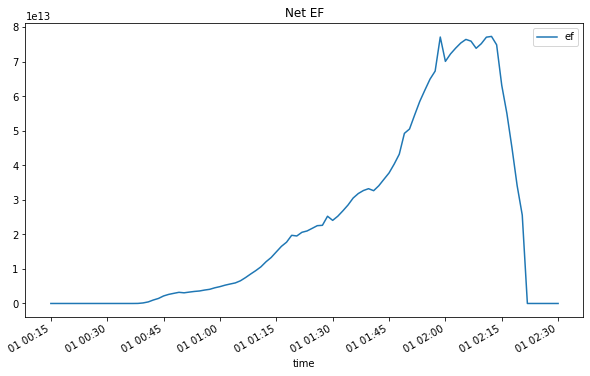

In [9]:
df.plot(
    x="time",
    y="ef",
    # c="ef",
    # vmin=-1e13,
    # vmax=1e13,
    title="Net EF",
)

In [11]:
print(df.rf_net_mean[20:70])

20    2.131933
21    2.623355
22    2.883796
23    3.134763
24    3.245367
25    3.409051
26    3.174528
27    3.064530
28    2.957191
29    3.075145
30    3.044585
31    3.232164
32    3.376668
33    3.591727
34    3.640242
35    3.653761
36    3.893768
37    4.034297
38    4.326570
39    4.648455
40    4.697972
41    4.910202
42    4.991223
43    5.186066
44    5.228600
45    5.433350
46    5.566180
47    5.689430
48    5.515147
49    5.660303
50    5.943584
51    6.087316
52    6.264355
53    6.414413
54    7.001478
55    7.174466
56    7.562185
57    7.947587
58    8.533630
59    8.673349
60    8.931753
61    8.720615
62    8.667624
63    8.456245
64    8.330580
65    8.180190
66    8.186381
67    8.004075
68    8.001675
69    8.111459
Name: rf_net_mean, dtype: float64
